In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import os


df_list = []
for item in os.listdir("results/"):
    if not item.endswith('.csv'):
        continue
    df = pd.read_csv("results/" + item)
    df_list.append(df.copy())
df = pd.concat(df_list, ignore_index=True)

df['x_parsed'] = df['x'].apply(lambda s: np.fromstring(s.strip('[]'), sep=' '))
df['x1'] = df['x_parsed'].apply(lambda arr: arr[0])
df['x2'] = df['x_parsed'].apply(lambda arr: arr[1])


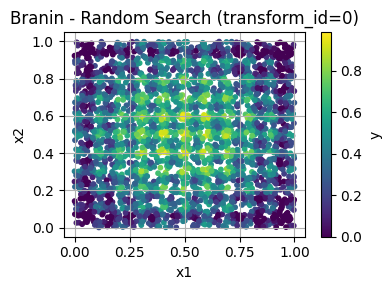

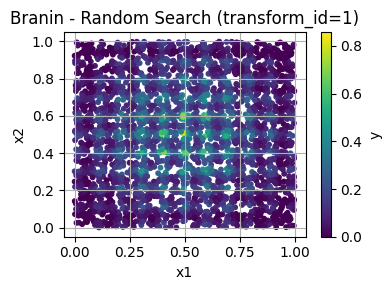

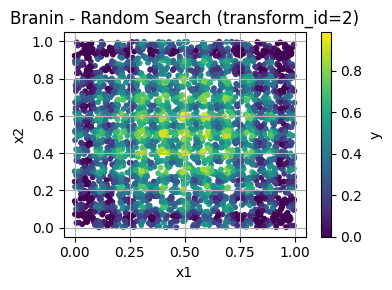

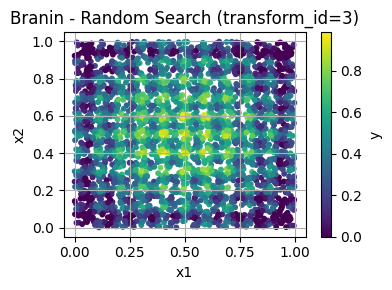

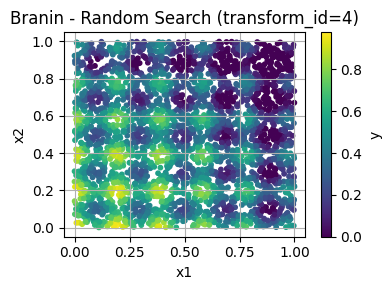

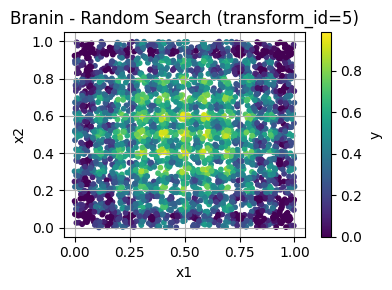

In [2]:
method = 'Random-Search'
function_name = "Rastrigin"
dfm = df[(df['method'] == method) & (df['function_name'] == function_name)]
# Plot for each transform_id
unique_transforms = dfm['transform_id'].unique()

for transform_id in unique_transforms:
    df_subset = dfm[dfm['transform_id'] == transform_id]
    
    plt.figure(figsize=(4, 3))
    sc = plt.scatter(df_subset['x1'], df_subset['x2'], c=df_subset['y'], cmap='viridis', s=10)
    plt.colorbar(sc, label='y')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f'Branin - Random Search (transform_id={transform_id})')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

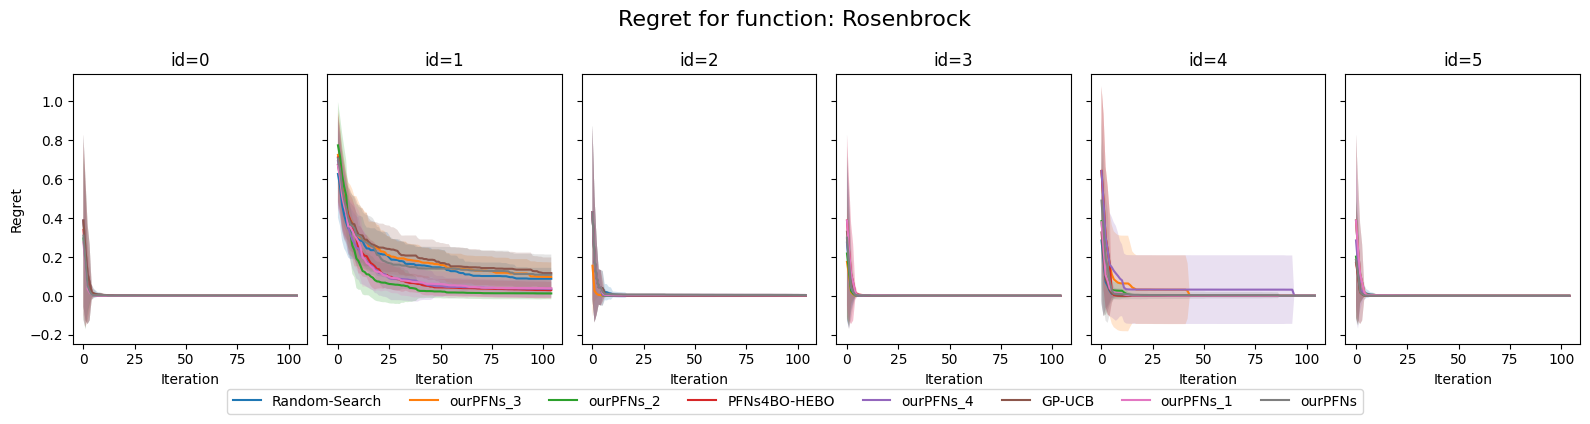

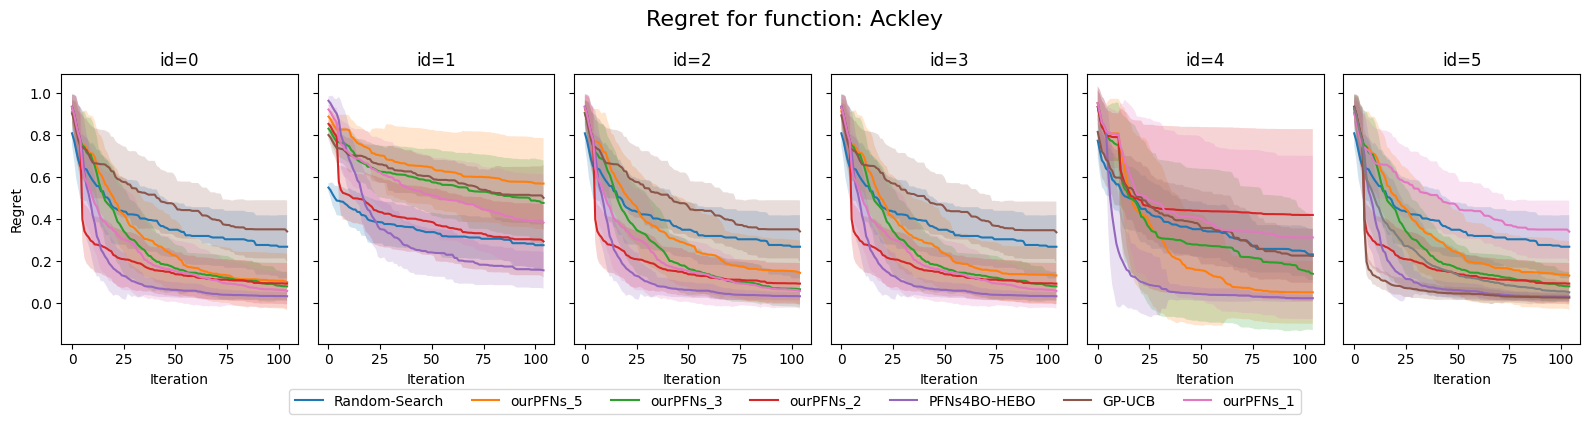

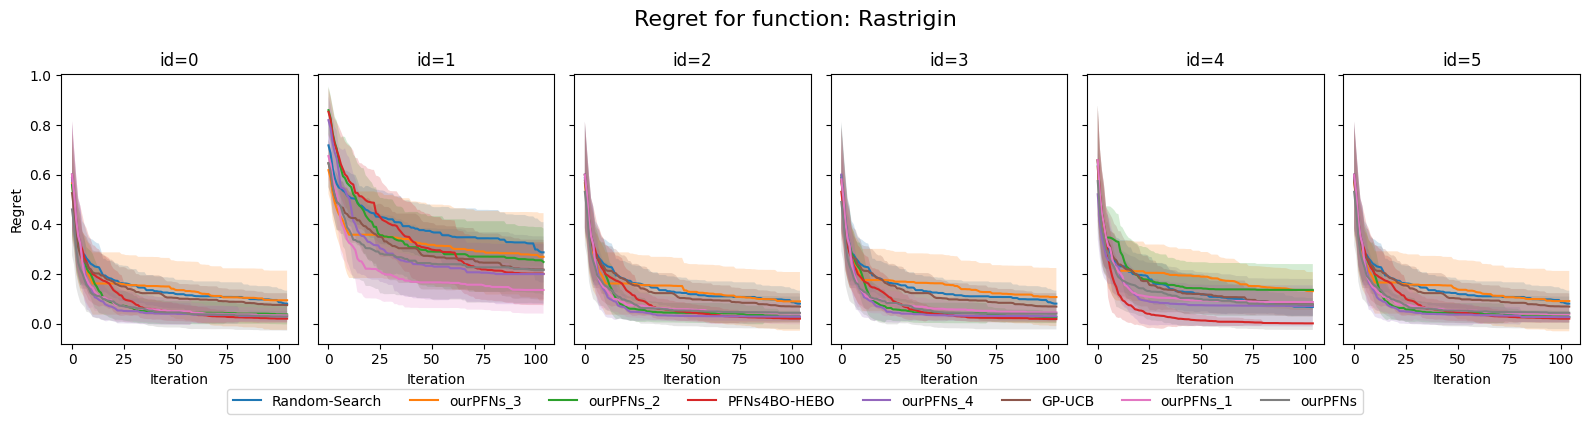

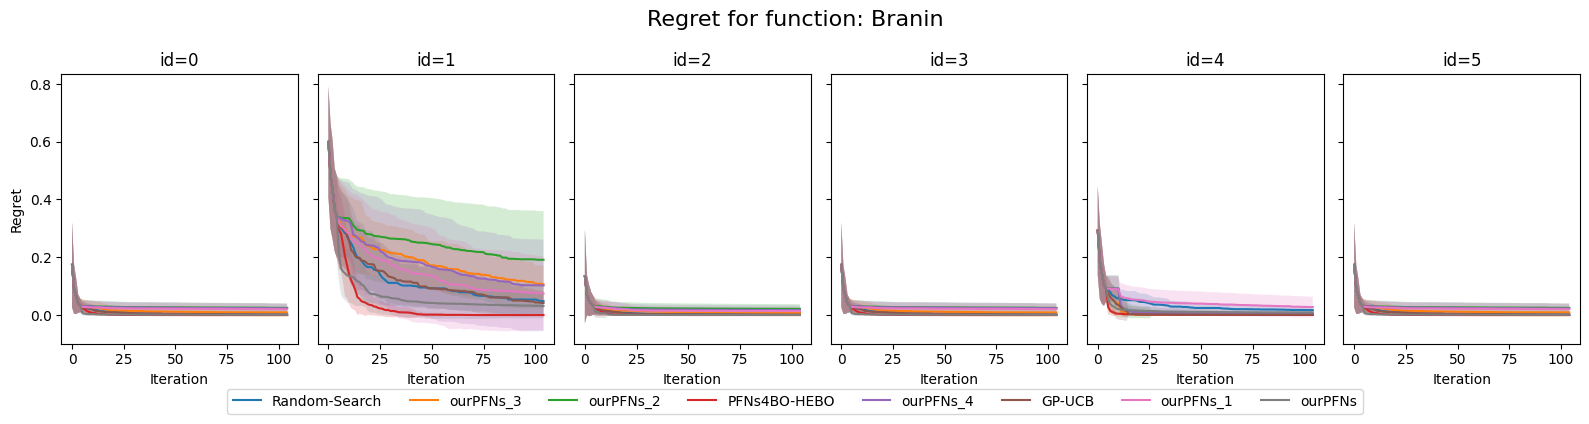

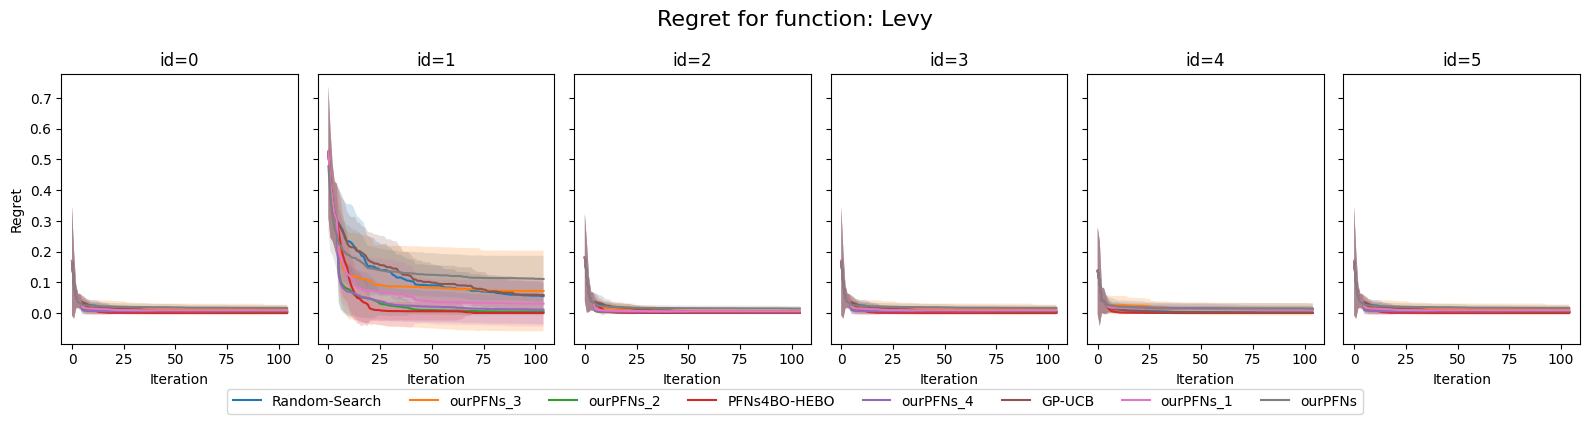

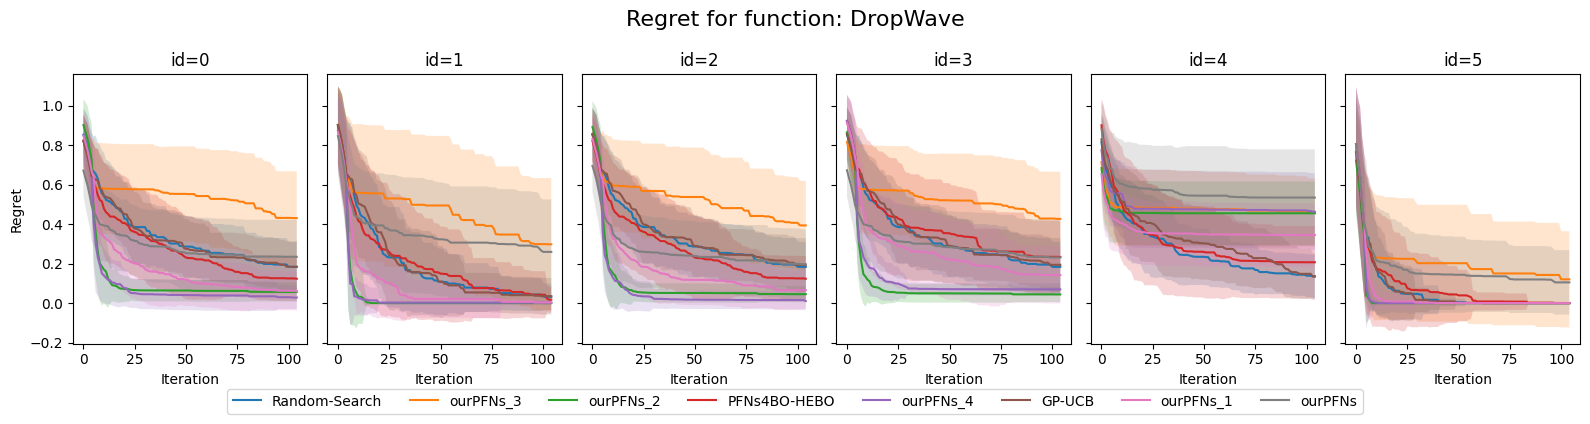

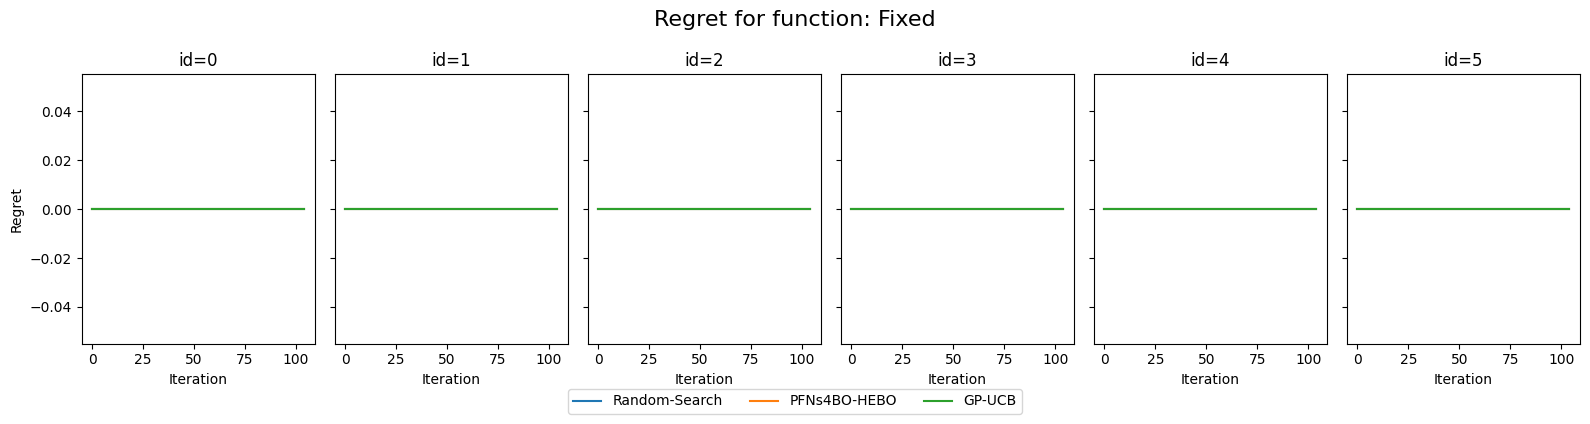

In [3]:
import matplotlib.pyplot as plt

function_names = df['function_name'].unique()
methods = df['method'].unique()

for function_name in function_names:
    fig, axes = plt.subplots(1, 6, figsize=(16, 4), sharey=True)  # 6 plots in one row
    handles = []
    labels = []
    collected_legend = False  # To avoid collecting multiple times
    for i, transform_id in enumerate(sorted(df['transform_id'].unique())):
        ax = axes[i]
        for method in methods:
            df_sub = df[
                (df['transform_id'] == transform_id) &
                (df['method'] == method) &
                (df['function_name'] == function_name)
            ]
            if df_sub.empty:
                continue
            y_star = df_sub['y'].max()
            pivot = df_sub.pivot(index='iteration', columns='seed', values='y').sort_index()
            incumbent = pivot.cummax()
            regret =  y_star - incumbent
            mean_regret = regret.mean(axis=1)
            std_regret = regret.std(axis=1)

            line, = ax.plot(mean_regret.index, mean_regret.values, label=method)
            ax.fill_between(mean_regret.index,
                            mean_regret - std_regret,
                            mean_regret + std_regret,
                            alpha=0.2)
            if not collected_legend:
                handles.append(line)
                labels.append(method)
                

        ax.set_title(f"id={transform_id}")
        ax.set_xlabel("Iteration")
        if i == 0:
            ax.set_ylabel("Regret")
        collected_legend = True

    fig.suptitle(f"Regret for function: {function_name}", fontsize=16)
    fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 0.05))
    fig.tight_layout()
    plt.show()


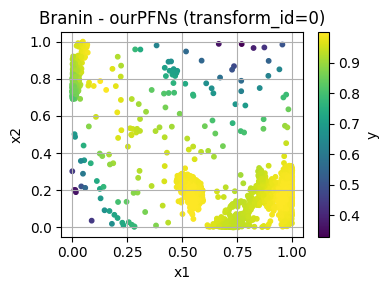

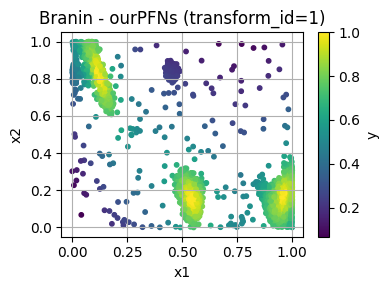

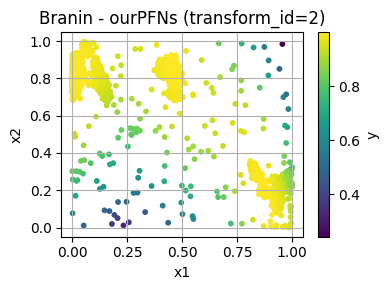

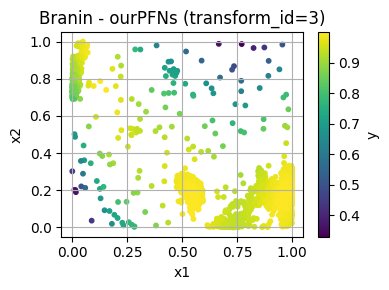

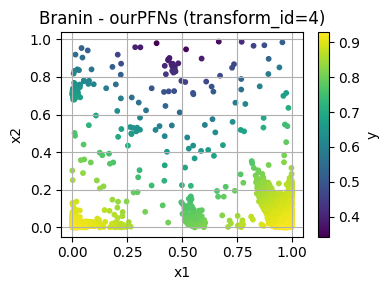

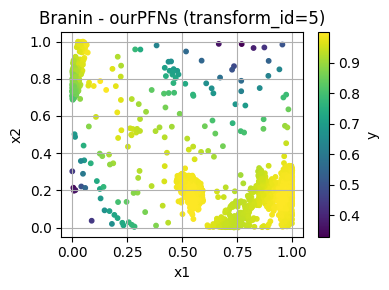

In [4]:
method = 'ourPFNs'
function_name = "Branin"
dfm = df[(df['method'] == method) & (df['function_name'] == function_name)]
# Plot for each transform_id
unique_transforms = dfm['transform_id'].unique()

for transform_id in unique_transforms:
    df_subset = dfm[dfm['transform_id'] == transform_id]
    
    plt.figure(figsize=(4, 3))
    sc = plt.scatter(df_subset['x1'], df_subset['x2'], c=df_subset['y'], cmap='viridis', s=10)
    plt.colorbar(sc, label='y')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f'{function_name} - {method} (transform_id={transform_id})')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

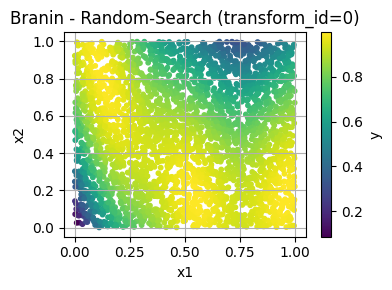

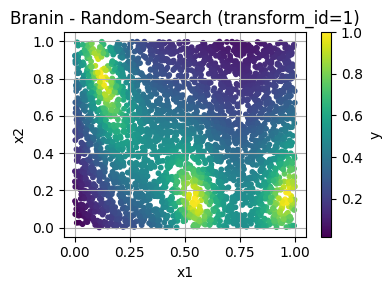

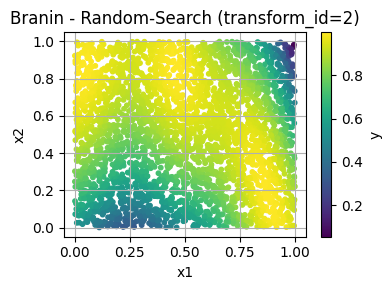

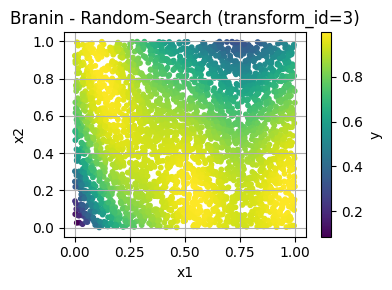

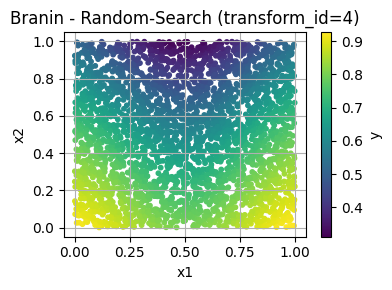

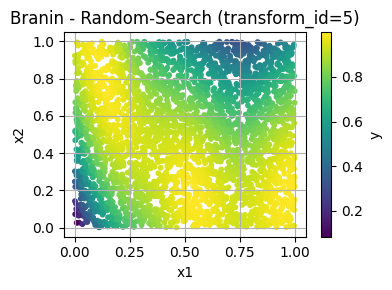

In [5]:
method = 'Random-Search'
function_name = "Branin"
dfm = df[(df['method'] == method) & (df['function_name'] == function_name)]
# Plot for each transform_id
unique_transforms = dfm['transform_id'].unique()

for transform_id in unique_transforms:
    df_subset = dfm[dfm['transform_id'] == transform_id]
    
    plt.figure(figsize=(4, 3))
    sc = plt.scatter(df_subset['x1'], df_subset['x2'], c=df_subset['y'], cmap='viridis', s=10)
    plt.colorbar(sc, label='y')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f'{function_name} - {method} (transform_id={transform_id})')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

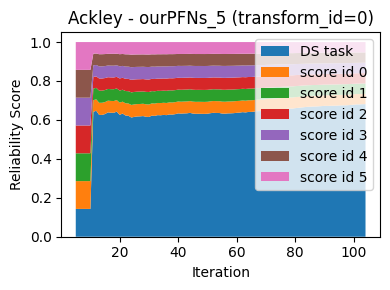

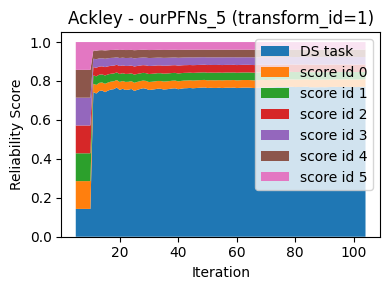

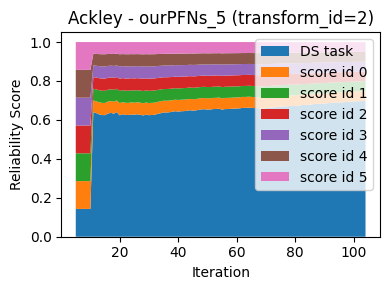

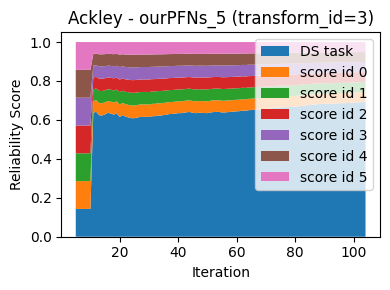

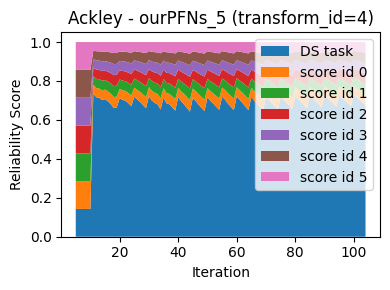

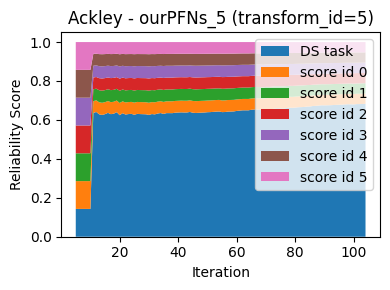

In [6]:
method = 'ourPFNs_5'
function_name = "Ackley"
dfm = df[(df['method'] == method) & (df['function_name'] == function_name)]
# Plot for each transform_id
unique_transforms = dfm['transform_id'].unique()

def parse_scores(x):
    if isinstance(x, str):
        if "tensor" in x:
            # Remove 'tensor(' and ')' and convert to numpy array
            x = x.replace('tensor(', '').replace(')', '').strip('[]')
        else:
            # Handle string representation of a list
           x = x.strip('[]')
        return np.array([float(i.strip()) if i.strip() != 'nan' else np.nan for i in x.split(',')])
    return np.array(x)


for transform_id in unique_transforms:
    df_subset = dfm[(dfm['transform_id'] == transform_id) & (dfm['iteration'] >= 5)].copy()

    df_subset['scores'] = df_subset['reliability_scores'].apply(parse_scores)

    score_cols = [f'DS task' if i==0 else f'score id {i -1}' for i in range(len(df_subset['scores'].iloc[0]))]

    df_subset[score_cols] = pd.DataFrame(df_subset['scores'].tolist(), index=df_subset.index)
    
    agg_df = df_subset.groupby('iteration')[score_cols].mean()  # or .median()

    plt.figure(figsize=(4, 3))
    plt.stackplot(agg_df.index, agg_df.values.T, labels=score_cols)
    plt.xlabel("Iteration")
    plt.ylabel("Reliability Score")
    plt.title(f'{function_name} - {method} (transform_id={transform_id})')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [7]:
context_y = [0.1477, 0.3452, 0.1964, 0.0266, 0.0000, 0.3480, 0.2778, 0.2924, 0.4285,
        0.0316, 0.0102, 0.0000]

imputed_y = [[ 9.3114e-01,  1.6719e+00,  1.3659e+00, -3.2874e-01, -7.1614e-01, 1.6077e+00,  1.5651e+00,  1.6470e+00,  1.7247e+00, -2.8842e-01, -4.7462e-01, -6.1116e-01],   
              [ 3.9614e-03,  2.8369e-03,  2.2174e-03,  3.8628e-03,  9.3060e-04, 2.8238e-03,  2.7907e-03,  2.8209e-03,  2.6596e-03,  1.0148e-02, 1.1065e-02,  9.9116e-03]]


In [8]:
import torch
import torch.nn.functional as F

# Example vectors
context_y = torch.tensor(context_y)
imputed_y = torch.tensor(imputed_y)

similarity = F.cosine_similarity(context_y.unsqueeze(0), imputed_y)
print(similarity) 

tensor([0.9409, 0.3891])


In [9]:
n_imputed_y = (imputed_y - imputed_y.min(dim = 1, keepdim=True).values) / (imputed_y.max(dim = 1, keepdim=True).values - imputed_y.min(dim = 1, keepdim=True).values)

In [10]:
n_imputed_y 

tensor([[0.6749, 0.9784, 0.8530, 0.1587, 0.0000, 0.9521, 0.9346, 0.9682, 1.0000,
         0.1752, 0.0989, 0.0430],
        [0.2991, 0.1881, 0.1270, 0.2893, 0.0000, 0.1868, 0.1835, 0.1865, 0.1706,
         0.9095, 1.0000, 0.8862]])

In [11]:
n_imputed_y 

tensor([[0.6749, 0.9784, 0.8530, 0.1587, 0.0000, 0.9521, 0.9346, 0.9682, 1.0000,
         0.1752, 0.0989, 0.0430],
        [0.2991, 0.1881, 0.1270, 0.2893, 0.0000, 0.1868, 0.1835, 0.1865, 0.1706,
         0.9095, 1.0000, 0.8862]])

In [12]:
projected_y  = ( n_imputed_y  + context_y.min() ) * (context_y.max() - context_y.min())

In [13]:
projected_y

tensor([[0.2892, 0.4192, 0.3655, 0.0680, 0.0000, 0.4080, 0.4005, 0.4149, 0.4285,
         0.0751, 0.0424, 0.0184],
        [0.1281, 0.0806, 0.0544, 0.1240, 0.0000, 0.0800, 0.0786, 0.0799, 0.0731,
         0.3897, 0.4285, 0.3797]])

In [14]:
rmse = np.sqrt(((context_y.unsqueeze(0)- projected_y)**2).mean(axis=1))
print(rmse)

tensor([0.0879, 0.2631])
